In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2

# Professional Aesthetic Settings
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)

print("Loading datasets...")
train_df = pd.read_csv('C:\\Users\\USER\\Downloads\\DigiCow\\data\\raw\\Train.csv')
test_df = pd.read_csv('C:\\Users\\USER\\Downloads\\DigiCow\\data\\raw\\Test.csv')
prior_df = pd.read_csv('C:\\Users\\USER\\Downloads\\DigiCow\\data\\raw\\Prior.csv')

# Clean columns
for df in [train_df, test_df, prior_df]:
    df.columns = df.columns.str.strip()

Loading datasets...


## The Temporal Covariate Shift Map
This block visualizes exactly why giving the model the raw dates caused your score to drop.
 
It plots the distribution of training months for both 2024 (Train) and 2025 (Test).

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.opti

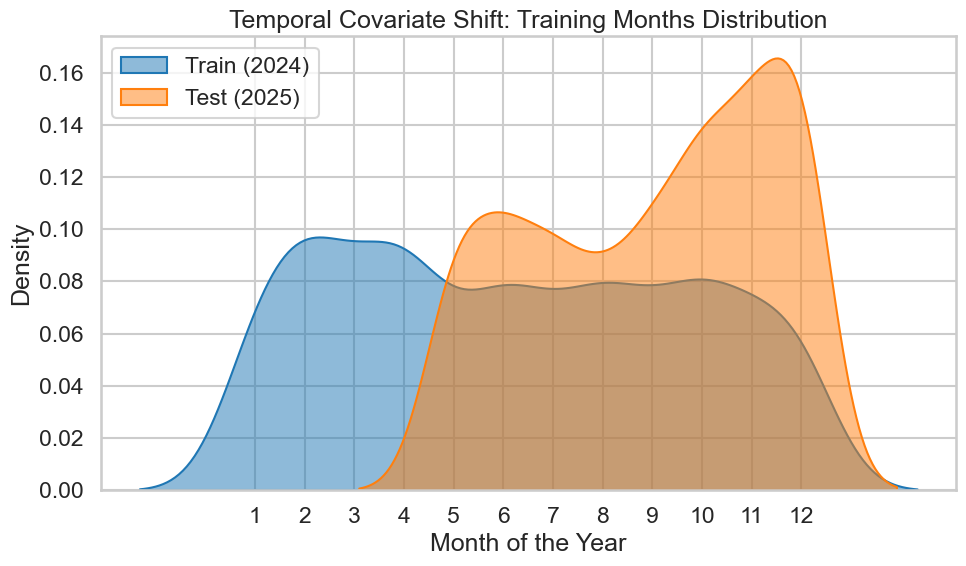

<Figure size 1200x600 with 0 Axes>

In [16]:
# Extract Month safely
train_dates = pd.to_datetime(train_df['training_day'], errors='coerce').dt.month.dropna()
test_dates = pd.to_datetime(test_df['training_day'], errors='coerce').dt.month.dropna()

plt.figure(figsize=(10, 6))
sns.kdeplot(train_dates, label='Train (2024)', fill=True, color='#1f77b4', alpha=0.5, bw_adjust=1.5)
sns.kdeplot(test_dates, label='Test (2025)', fill=True, color='#ff7f0e', alpha=0.5, bw_adjust=1.5)

plt.title("Temporal Covariate Shift: Training Months Distribution")
plt.xlabel("Month of the Year")
plt.ylabel("Density")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('C:\\Users\\USER\\Downloads\\DigiCow\\screenshots\\temporal_covariate_shift.png', facecolor='white', transparent=False, bbox_inches='tight')

## The Entity Overlap (Cold Start Matrix)
This generates Venn diagrams to show exactly how many farmers and trainers in the Test set are completely brand new (Cold Starts) and have zero history in the Train or Prior datasets.

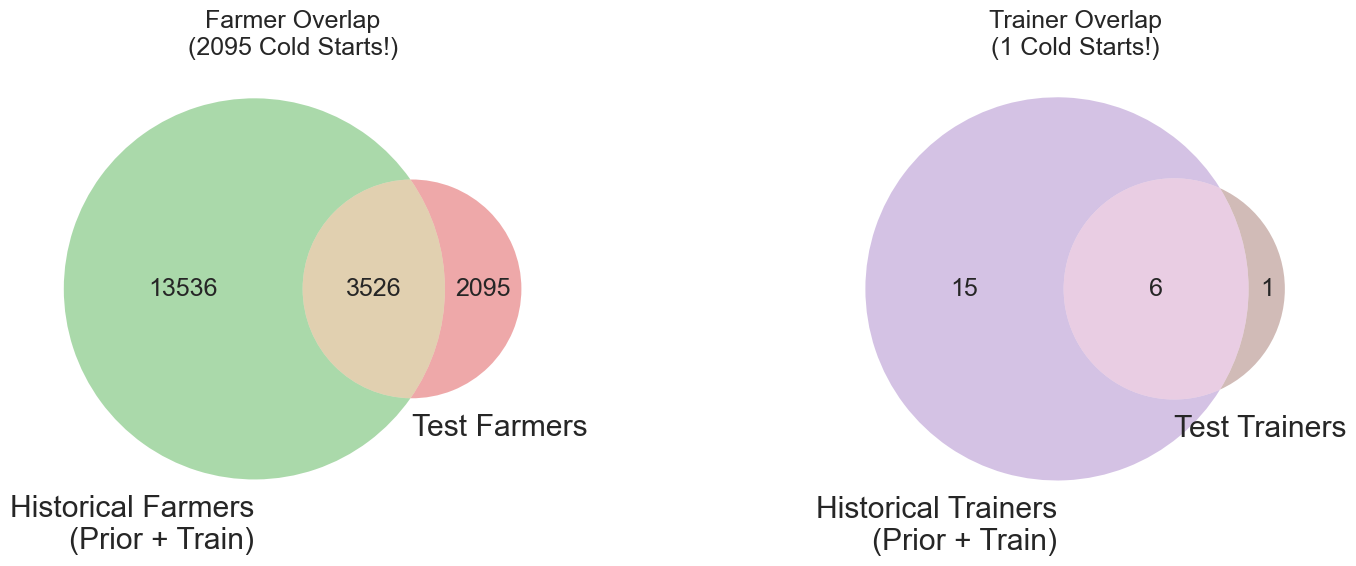

<Figure size 1200x600 with 0 Axes>

In [17]:
# Combine history (Prior + Train)
historical_farmers = set(prior_df['farmer_name']).union(set(train_df['farmer_name']))
historical_trainers = set(prior_df['trainer']).union(set(train_df['trainer']))

test_farmers = set(test_df['farmer_name'])
test_trainers = set(test_df['trainer'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Farmer Venn
venn2([historical_farmers, test_farmers], 
      set_labels=('Historical Farmers\n(Prior + Train)', 'Test Farmers'), 
      ax=axes[0], set_colors=('#2ca02c', '#d62728'))
axes[0].set_title(f"Farmer Overlap\n({len(test_farmers - historical_farmers)} Cold Starts!)")

# Trainer Venn
venn2([historical_trainers, test_trainers], 
      set_labels=('Historical Trainers\n(Prior + Train)', 'Test Trainers'), 
      ax=axes[1], set_colors=('#9467bd', '#8c564b'))
axes[1].set_title(f"Trainer Overlap\n({len(test_trainers - historical_trainers)} Cold Starts!)")

plt.tight_layout()
plt.show()
plt.savefig('C:\\Users\\USER\\Downloads\\DigiCow\\screenshots\\cold_start_venn.png', facecolor='white', transparent=False, bbox_inches='tight')

## The Multi-Horizon Adoption Rate
This creates a step-chart showing the growth of adoption across the three time horizons.

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype

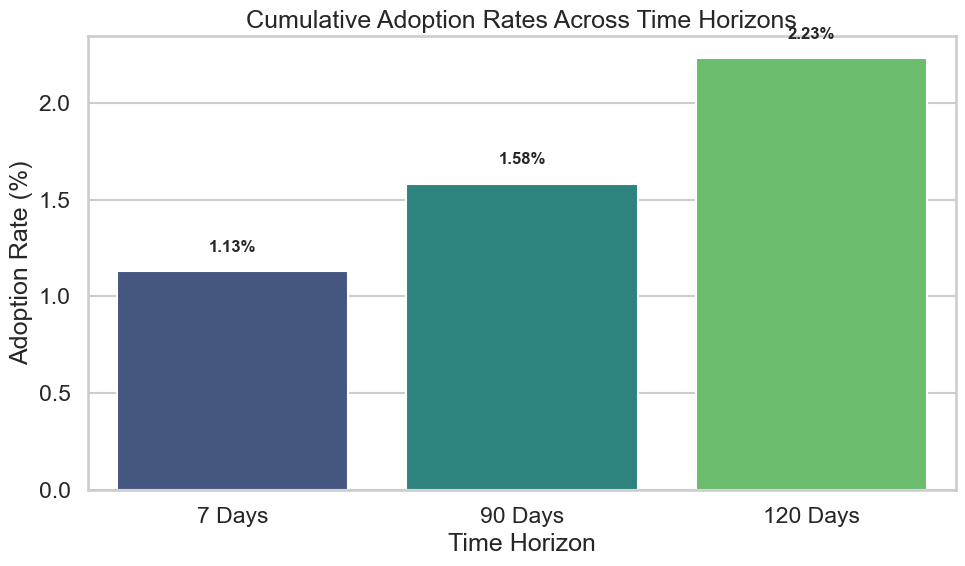

<Figure size 1200x600 with 0 Axes>

In [18]:
targets = ['adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days']
adoption_rates = train_df[targets].mean() * 100 # Convert to percentage

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=['7 Days', '90 Days', '120 Days'], y=adoption_rates.values, palette='viridis')

plt.title("Cumulative Adoption Rates Across Time Horizons")
plt.ylabel("Adoption Rate (%)")
plt.xlabel("Time Horizon")

# Add percentage labels on top of bars
for i, v in enumerate(adoption_rates.values):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()
plt.savefig('C:\\Users\\USER\\Downloads\\DigiCow\\screenshots\\adoption_rates.png', facecolor='white', transparent=False, bbox_inches='tight')

## NLP Topic Dominance vs. Success Matrix
This is the holy grail visual. It plots every single training topic. 

The X-axis is how often it was taught, and the Y-axis is how successful it was at driving 7-day adoption.

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


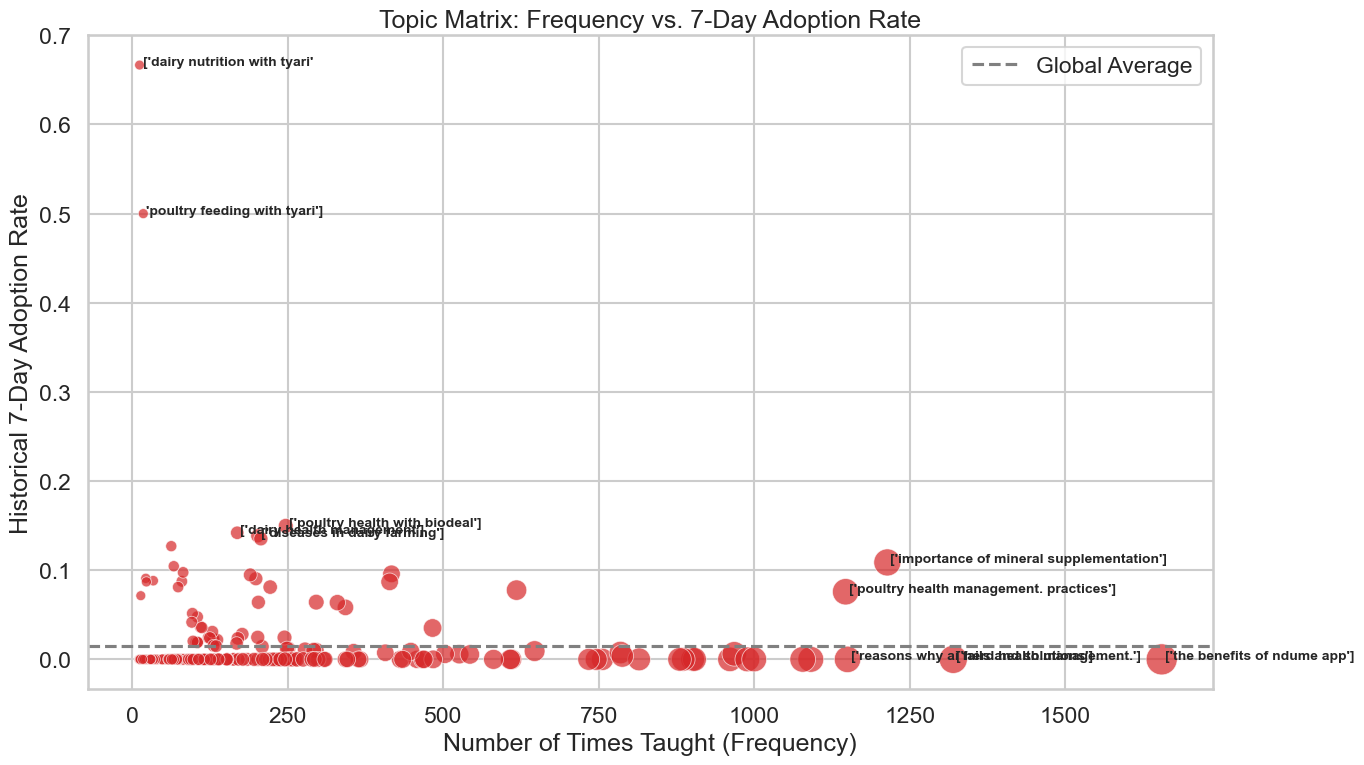

<Figure size 1200x600 with 0 Axes>

In [19]:
# We need to calculate this from Prior to prevent data leakage in our logic
topic_col = 'topics_list' if 'topics_list' in prior_df.columns else 'topics'

# Explode the comma-separated topics so we can analyze them individually
prior_df['clean_topics'] = prior_df[topic_col].fillna('unknown').astype(str).str.lower()
exploded_topics = prior_df.assign(clean_topics=prior_df['clean_topics'].str.split(',')).explode('clean_topics')
exploded_topics['clean_topics'] = exploded_topics['clean_topics'].str.strip()

topic_stats = exploded_topics.groupby('clean_topics').agg(
    frequency=('ID', 'count'),
    adoption_rate_07=('adopted_within_07_days', 'mean')
).reset_index()

# Filter out extreme outliers (topics taught only 1 or 2 times) for a clean plot
topic_stats = topic_stats[topic_stats['frequency'] > 10]

plt.figure(figsize=(14, 8))
sns.scatterplot(data=topic_stats, x='frequency', y='adoption_rate_07', 
                size='frequency', sizes=(50, 500), alpha=0.7, color='#d62728', legend=False)

# Annotate the most interesting topics (High frequency OR High adoption)
top_freq = topic_stats.nlargest(5, 'frequency')
top_adopt = topic_stats.nlargest(5, 'adoption_rate_07')
interesting_topics = pd.concat([top_freq, top_adopt]).drop_duplicates()

for i in range(len(interesting_topics)):
    plt.text(interesting_topics['frequency'].iloc[i] + 5, 
             interesting_topics['adoption_rate_07'].iloc[i], 
             interesting_topics['clean_topics'].iloc[i], 
             fontsize=10, weight='bold')

plt.title("Topic Matrix: Frequency vs. 7-Day Adoption Rate")
plt.xlabel("Number of Times Taught (Frequency)")
plt.ylabel("Historical 7-Day Adoption Rate")
plt.axhline(prior_df['adopted_within_07_days'].mean(), color='grey', linestyle='--', label='Global Average')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('C:\\Users\\USER\\Downloads\\DigiCow\\screenshots\\topic_matrix.png', facecolor='white', transparent=False, bbox_inches='tight')